# Class (Logistic Regression vs SGDClassifier (log-loss) vs SVMClassifier vs SGDClassifier (hinge) vs KNeighborsClassifier vs )

In [137]:
!pip install imbalanced-learn


   ---------------------------------------- 0/2 [sklearn-compat]
   -------------------- ------------------- 1/2 [imbalanced-learn]
   -------------------- ------------------- 1/2 [imbalanced-learn]
   -------------------- ------------------- 1/2 [imbalanced-learn]
   -------------------- ------------------- 1/2 [imbalanced-learn]
   -------------------- ------------------- 1/2 [imbalanced-learn]
   -------------------- ------------------- 1/2 [imbalanced-learn]
   -------------------- ------------------- 1/2 [imbalanced-learn]
   -------------------- ------------------- 1/2 [imbalanced-learn]
   ---------------------------------------- 2/2 [imbalanced-learn]



In [161]:
import pandas as pd
from sklearn.neural_network import MLPClassifier
from sklearn.linear_model import LogisticRegression, SGDClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import OneHotEncoder, LabelEncoder, OrdinalEncoder, StandardScaler
from statsmodels.api import Logit
from statsmodels.formula.api import logit
from sklearn.metrics import accuracy_score, RocCurveDisplay, classification_report, ConfusionMatrixDisplay
import matplotlib.pyplot as pd
import pandas as pd
from sklearn.model_selection import train_test_split, GridSearchCV
import matplotlib.pyplot as plt
from imblearn.over_sampling import SMOTE

## Tại sao các mô hình (LogisticRegression vs SGDClassifier vs MLPClassifier cho biến categorical phải xóa đi cột đầu tiên)? (trả lời đúng sẽ cộng điểm)

## Load Data

In [ ]:
df_train = pd.read_csv('data/hr_train.csv')
df_train.head()

,employee_id,department,region,education,gender,recruitment_channel,no_of_trainings,age,previous_year_rating,length_of_service,KPIs_met >80%,awards_won?,avg_training_score,is_promoted
0,65438,Sales & Marketing,region_7,Master's & above,f,sourcing,1,35,5.0,8,1,0,49,0
1,65141,Operations,region_22,Bachelor's,m,other,1,30,5.0,4,0,0,60,0
2,7513,Sales & Marketing,region_19,Bachelor's,m,sourcing,1,34,3.0,7,0,0,50,0
3,2542,Sales & Marketing,region_23,Bachelor's,m,other,2,39,1.0,10,0,0,50,0
4,48945,Technology,region_26,Bachelor's,m,other,1,45,3.0,2,0,0,73,0


## Unimbalanced

In [ ]:
promoted = df_train['is_promoted'].value_counts()
promoted.index

Index([0, 1], dtype='int64', name='is_promoted')

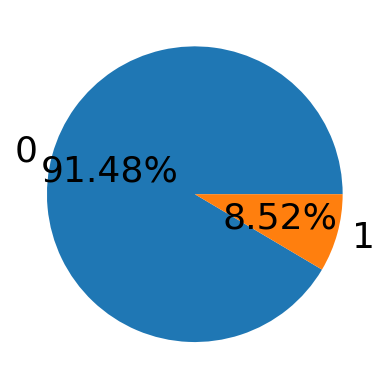

In [ ]:
plt.pie(x = promoted, labels=promoted.index, autopct='%.2f%%')
plt.show()

## 1. drop vs drop model (classifier)

In [95]:
df_train['education'].value_counts()

education
Bachelor's          36669
Master's & above    14925
Below Secondary       805
Name: count, dtype: int64

In [96]:
df_train['previous_year_rating'].value_counts()

previous_year_rating
3.0    18618
5.0    11741
4.0     9877
1.0     6223
2.0     4225
Name: count, dtype: int64

## 2. Preprocessing

### 2.1 Remove <b>employee_id<b>

In [97]:
df_train.drop(columns='employee_id', inplace= True)

### 2.2 Check null data

In [98]:
df_train.shape, df_train.isna().sum()

((54808, 13),
 department                 0
 region                     0
 education               2409
 gender                     0
 recruitment_channel        0
 no_of_trainings            0
 age                        0
 previous_year_rating    4124
 length_of_service          0
 KPIs_met >80%              0
 awards_won?                0
 avg_training_score         0
 is_promoted                0
 dtype: int64)

### 2.3 Process drop data (native)

In [99]:
df_train.dropna().shape[0] * 100 / df_train.shape[0]

88.78265946577142

In [100]:
df_drop =  df_train.dropna().copy()
df_drop.head()

,department,region,education,gender,recruitment_channel,no_of_trainings,age,previous_year_rating,length_of_service,KPIs_met >80%,awards_won?,avg_training_score,is_promoted
0,Sales & Marketing,region_7,Master's & above,f,sourcing,1,35,5.0,8,1,0,49,0
1,Operations,region_22,Bachelor's,m,other,1,30,5.0,4,0,0,60,0
2,Sales & Marketing,region_19,Bachelor's,m,sourcing,1,34,3.0,7,0,0,50,0
3,Sales & Marketing,region_23,Bachelor's,m,other,2,39,1.0,10,0,0,50,0
4,Technology,region_26,Bachelor's,m,other,1,45,3.0,2,0,0,73,0


### rename column

In [101]:
df_drop.rename(columns={'KPIs_met >80%': 'KPI_met', 'awards_won?': 'awards_won'}, inplace=True)

In [102]:
df_drop.head()

,department,region,education,gender,recruitment_channel,no_of_trainings,age,previous_year_rating,length_of_service,KPI_met,awards_won,avg_training_score,is_promoted
0,Sales & Marketing,region_7,Master's & above,f,sourcing,1,35,5.0,8,1,0,49,0
1,Operations,region_22,Bachelor's,m,other,1,30,5.0,4,0,0,60,0
2,Sales & Marketing,region_19,Bachelor's,m,sourcing,1,34,3.0,7,0,0,50,0
3,Sales & Marketing,region_23,Bachelor's,m,other,2,39,1.0,10,0,0,50,0
4,Technology,region_26,Bachelor's,m,other,1,45,3.0,2,0,0,73,0


### Using formular logit

In [103]:
df_drop.columns

Index(['department', 'region', 'education', 'gender', 'recruitment_channel',
       'no_of_trainings', 'age', 'previous_year_rating', 'length_of_service',
       'KPI_met', 'awards_won', 'avg_training_score', 'is_promoted'],
      dtype='object')

In [104]:
model = logit(formula='is_promoted ~ department + region + education + gender + recruitment_channel + no_of_trainings + age + previous_year_rating + length_of_service + KPI_met + awards_won + avg_training_score ', data=df_drop).fit()
model.summary()

Optimization terminated successfully.
         Current function value: 0.198861
         Iterations 8


<class 'statsmodels.iolib.summary.Summary'>
"""
                           Logit Regression Results                           
==============================================================================
Dep. Variable:            is_promoted   No. Observations:                48660
Model:                          Logit   Df Residuals:                    48606
Method:                           MLE   Df Model:                           53
Date:                Fri, 13 Mar 2026   Pseudo R-squ.:                  0.3270
Time:                        10:11:52   Log-Likelihood:                -9676.6
converged:                       True   LL-Null:                       -14378.
Covariance Type:            nonrobust   LLR p-value:                     0.000
===================================================================================================
                                      coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------------------------
Intercept                         -29.8469      0.523    -57.056      0.000     -30.872     -28.822
department[T.Finance]               7.1201      0.170     41.945      0.000       6.787       7.453
department[T.HR]                   10.0359      0.224     44.888      0.000       9.598      10.474
department[T.Legal]                 6.9041      0.231     29.828      0.000       6.450       7.358
department[T.Operations]            7.3415      0.149     49.219      0.000       7.049       7.634
department[T.Procurement]           4.4640      0.111     40.178      0.000       4.246       4.682
department[T.R&D]                  -0.6432      0.160     -4.032      0.000      -0.956      -0.331
department[T.Sales & Marketing]    10.5273      0.199     53.013      0.000      10.138      10.917
department[T.Technology]            1.7442      0.081     21.589      0.000       1.586       1.903
region[T.region_10]                 0.0903      0.247      0.366      0.715      -0.394       0.574
region[T.region_11]                -0.3597      0.225     -1.598      0.110      -0.801       0.082
region[T.region_12]                -0.6110      0.322     -1.900      0.057      -1.241       0.019
region[T.region_13]                 0.0115      0.194      0.059      0.953      -0.368       0.391
region[T.region_14]                -0.0527      0.234     -0.226      0.822      -0.511       0.405
region[T.region_15]                 0.0433      0.194      0.223      0.824      -0.337       0.424
region[T.region_16]                -0.1862      0.216     -0.861      0.389      -0.610       0.238
region[T.region_17]                 0.4632      0.220      2.107      0.035       0.032       0.894
region[T.region_18]                 0.5215      1.075      0.485      0.627      -1.585       2.628
region[T.region_19]                -0.1143      0.241     -0.475      0.635      -0.586       0.358
region[T.region_2]                  0.1353      0.180      0.752      0.452      -0.217       0.488
region[T.region_20]                -0.4156      0.252     -1.650      0.099      -0.909       0.078
region[T.region_21]                -0.3835      0.323     -1.185      0.236      -1.017       0.251
region[T.region_22]                 0.4411      0.181      2.440      0.015       0.087       0.795
region[T.region_23]                 0.3958      0.206      1.924      0.054      -0.007       0.799
region[T.region_24]                -0.2740      0.314     -0.874      0.382      -0.889       0.341
region[T.region_25]                 0.5282      0.216      2.444      0.015       0.105       0.952
region[T.region_26]                -0.0919      0.202     -0.454      0.650      -0.489       0.305
region[T.region_27]                 0.0484      0.208      0.232      0.816      -0.360       0.457
region[T.region_28]                 0.2739      0.205      1.333      0.183      -0.129       0.677
region[T.region_29]                -0.611

In [105]:
df_drop.columns

Index(['department', 'region', 'education', 'gender', 'recruitment_channel',
       'no_of_trainings', 'age', 'previous_year_rating', 'length_of_service',
       'KPI_met', 'awards_won', 'avg_training_score', 'is_promoted'],
      dtype='object')

### OneHotEncoder

In [106]:
encoder = OneHotEncoder(sparse_output=False, dtype=int)
encoder.fit_transform(df_drop[['recruitment_channel']])

array([[0, 0, 1],
       [1, 0, 0],
       [0, 0, 1],
       ...,
       [1, 0, 0],
       [1, 0, 0],
       [1, 0, 0]], shape=(48660, 3))

### OneHotEncoder drop first

In [107]:
encoder = OneHotEncoder(sparse_output=False, dtype=int, drop='first')
encoder.fit_transform(df_drop[['recruitment_channel']])

array([[0, 1],
       [0, 0],
       [0, 1],
       ...,
       [0, 0],
       [0, 0],
       [0, 0]], shape=(48660, 2))

In [108]:
df_drop['recruitment_channel'].value_counts()

recruitment_channel
other       27017
sourcing    20623
referred     1020
Name: count, dtype: int64

In [109]:
df_drop.dtypes

department               object
region                   object
education                object
gender                   object
recruitment_channel      object
no_of_trainings           int64
age                       int64
previous_year_rating    float64
length_of_service         int64
KPI_met                   int64
awards_won                int64
avg_training_score        int64
is_promoted               int64
dtype: object

### Find categorical binary or multiple value

In [110]:
cols_bin = []
cols_mult = []
for col in df_drop.columns:
    if df_drop[col].dtype == object:
        if df_drop[col].nunique() > 2:
            cols_mult.append(col)
        else:
            cols_bin.append(col)
cols_bin, cols_mult

(['gender'], ['department', 'region', 'education', 'recruitment_channel'])

### processing binary <b>gender<b>

In [111]:
encoder = LabelEncoder()
df_drop['gender'] = encoder.fit_transform(df_drop['gender'])

### Processing categorical multiple value

In [112]:
df_drop = pd.get_dummies(columns=['department', 'region', 'education', 'recruitment_channel'], data=df_drop, dtype=int, drop_first=True)

In [113]:
df_drop.head()

,gender,no_of_trainings,age,previous_year_rating,length_of_service,KPI_met,awards_won,avg_training_score,is_promoted,department_Finance,...,region_region_4,region_region_5,region_region_6,region_region_7,region_region_8,region_region_9,education_Below Secondary,education_Master's & above,recruitment_channel_referred,recruitment_channel_sourcing
0,0,1,35,5.0,8,1,0,49,0,0,...,0,0,0,1,0,0,0,1,0,1
1,1,1,30,5.0,4,0,0,60,0,0,...,0,0,0,0,0,0,0,0,0,0
2,1,1,34,3.0,7,0,0,50,0,0,...,0,0,0,0,0,0,0,0,0,1
3,1,2,39,1.0,10,0,0,50,0,0,...,0,0,0,0,0,0,0,0,0,0
4,1,1,45,3.0,2,0,0,73,0,0,...,0,0,0,0,0,0,0,0,0,0


### Load data test

In [114]:
df_test = pd.read_csv('data/hr_test.csv')
df_test.head()

,employee_id,department,region,education,gender,recruitment_channel,no_of_trainings,age,previous_year_rating,length_of_service,KPIs_met >80%,awards_won?,avg_training_score
0,8724,Technology,region_26,Bachelor's,m,sourcing,1,24,NaN,1,1,0,77
1,74430,HR,region_4,Bachelor's,f,other,1,31,3.0,5,0,0,51
2,72255,Sales & Marketing,region_13,Bachelor's,m,other,1,31,1.0,4,0,0,47
3,38562,Procurement,region_2,Bachelor's,f,other,3,31,2.0,9,0,0,65
4,64486,Finance,region_29,Bachelor's,m,sourcing,1,30,4.0,7,0,0,61


In [115]:
df_test.isna().sum()

employee_id                0
department                 0
region                     0
education               1034
gender                     0
recruitment_channel        0
no_of_trainings            0
age                        0
previous_year_rating    1812
length_of_service          0
KPIs_met >80%              0
awards_won?                0
avg_training_score         0
dtype: int64

In [116]:
df_test.dropna().shape[0] * 100 / df_test.shape[0]

88.62920391656024

In [117]:
df_test.dropna(inplace=True)

In [118]:
df_test.drop(columns=['employee_id'], inplace=True)

In [119]:
df_test.head()

,department,region,education,gender,recruitment_channel,no_of_trainings,age,previous_year_rating,length_of_service,KPIs_met >80%,awards_won?,avg_training_score
1,HR,region_4,Bachelor's,f,other,1,31,3.0,5,0,0,51
2,Sales & Marketing,region_13,Bachelor's,m,other,1,31,1.0,4,0,0,47
3,Procurement,region_2,Bachelor's,f,other,3,31,2.0,9,0,0,65
4,Finance,region_29,Bachelor's,m,sourcing,1,30,4.0,7,0,0,61
5,Procurement,region_7,Bachelor's,m,sourcing,1,36,3.0,2,0,0,68


In [120]:
df_test['gender'] = encoder.transform(df_test['gender'])

In [121]:
df_test.rename(columns={'KPIs_met >80%': 'KPI_met', 'awards_won?': 'awards_won'}, inplace=True)

In [122]:
df_test.columns

Index(['department', 'region', 'education', 'gender', 'recruitment_channel',
       'no_of_trainings', 'age', 'previous_year_rating', 'length_of_service',
       'KPI_met', 'awards_won', 'avg_training_score'],
      dtype='object')

In [123]:
df_test = pd.get_dummies(df_test, columns=['department', 'region', 'education', 'recruitment_channel'], dtype=int, drop_first=True)
df_test.head()

,gender,no_of_trainings,age,previous_year_rating,length_of_service,KPI_met,awards_won,avg_training_score,department_Finance,department_HR,...,region_region_4,region_region_5,region_region_6,region_region_7,region_region_8,region_region_9,education_Below Secondary,education_Master's & above,recruitment_channel_referred,recruitment_channel_sourcing
1,0,1,31,3.0,5,0,0,51,0,1,...,1,0,0,0,0,0,0,0,0,0
2,1,1,31,1.0,4,0,0,47,0,0,...,0,0,0,0,0,0,0,0,0,0
3,0,3,31,2.0,9,0,0,65,0,0,...,0,0,0,0,0,0,0,0,0,0
4,1,1,30,4.0,7,0,0,61,1,0,...,0,0,0,0,0,0,0,0,0,1
5,1,1,36,3.0,2,0,0,68,0,0,...,0,0,0,1,0,0,0,0,0,1


In [184]:

X = df_drop.drop(columns='is_promoted')
y = df_drop['is_promoted']
X_train, X_val, y_train, y_val = train_test_split(X, y, random_state=2026)
X_test = df_test
lg = LogisticRegression(max_iter=5000, random_state=2026)
lg.fit(X_train, y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",2026
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

### Accuracy validation

In [147]:
lg.score(X_train, y_train), lg.score(X_val, y_val)

(0.9309768461433073, 0.9285655569256063)

### Confusion matrix

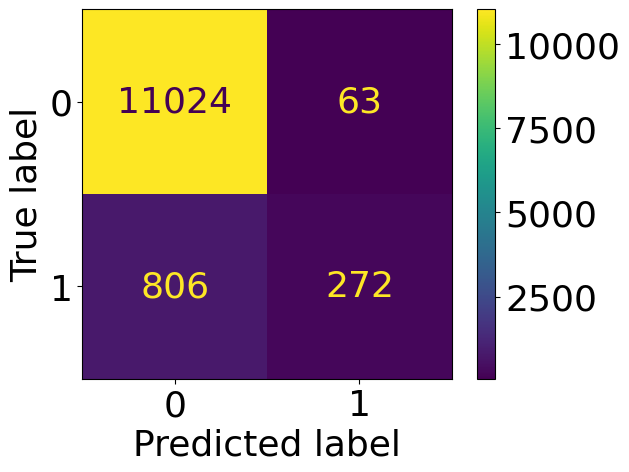

In [148]:
ConfusionMatrixDisplay.from_estimator(lg, X_val, y_val)
plt.show()

<Figure size 2000x1000 with 0 Axes>

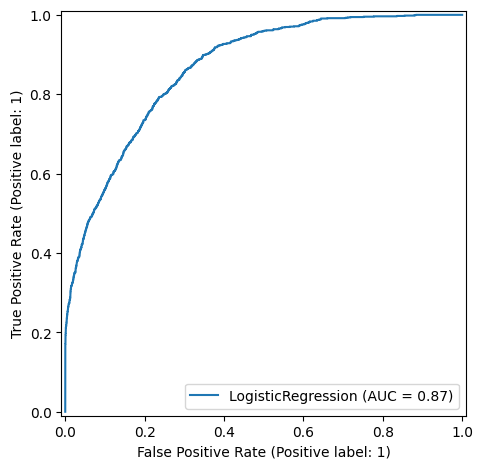

In [206]:
plt.rcParams['font.size'] = 10
plt.figure(figsize=(20,10))
RocCurveDisplay.from_estimator(lg, X_val, y_val)
plt.tight_layout()
plt.show()

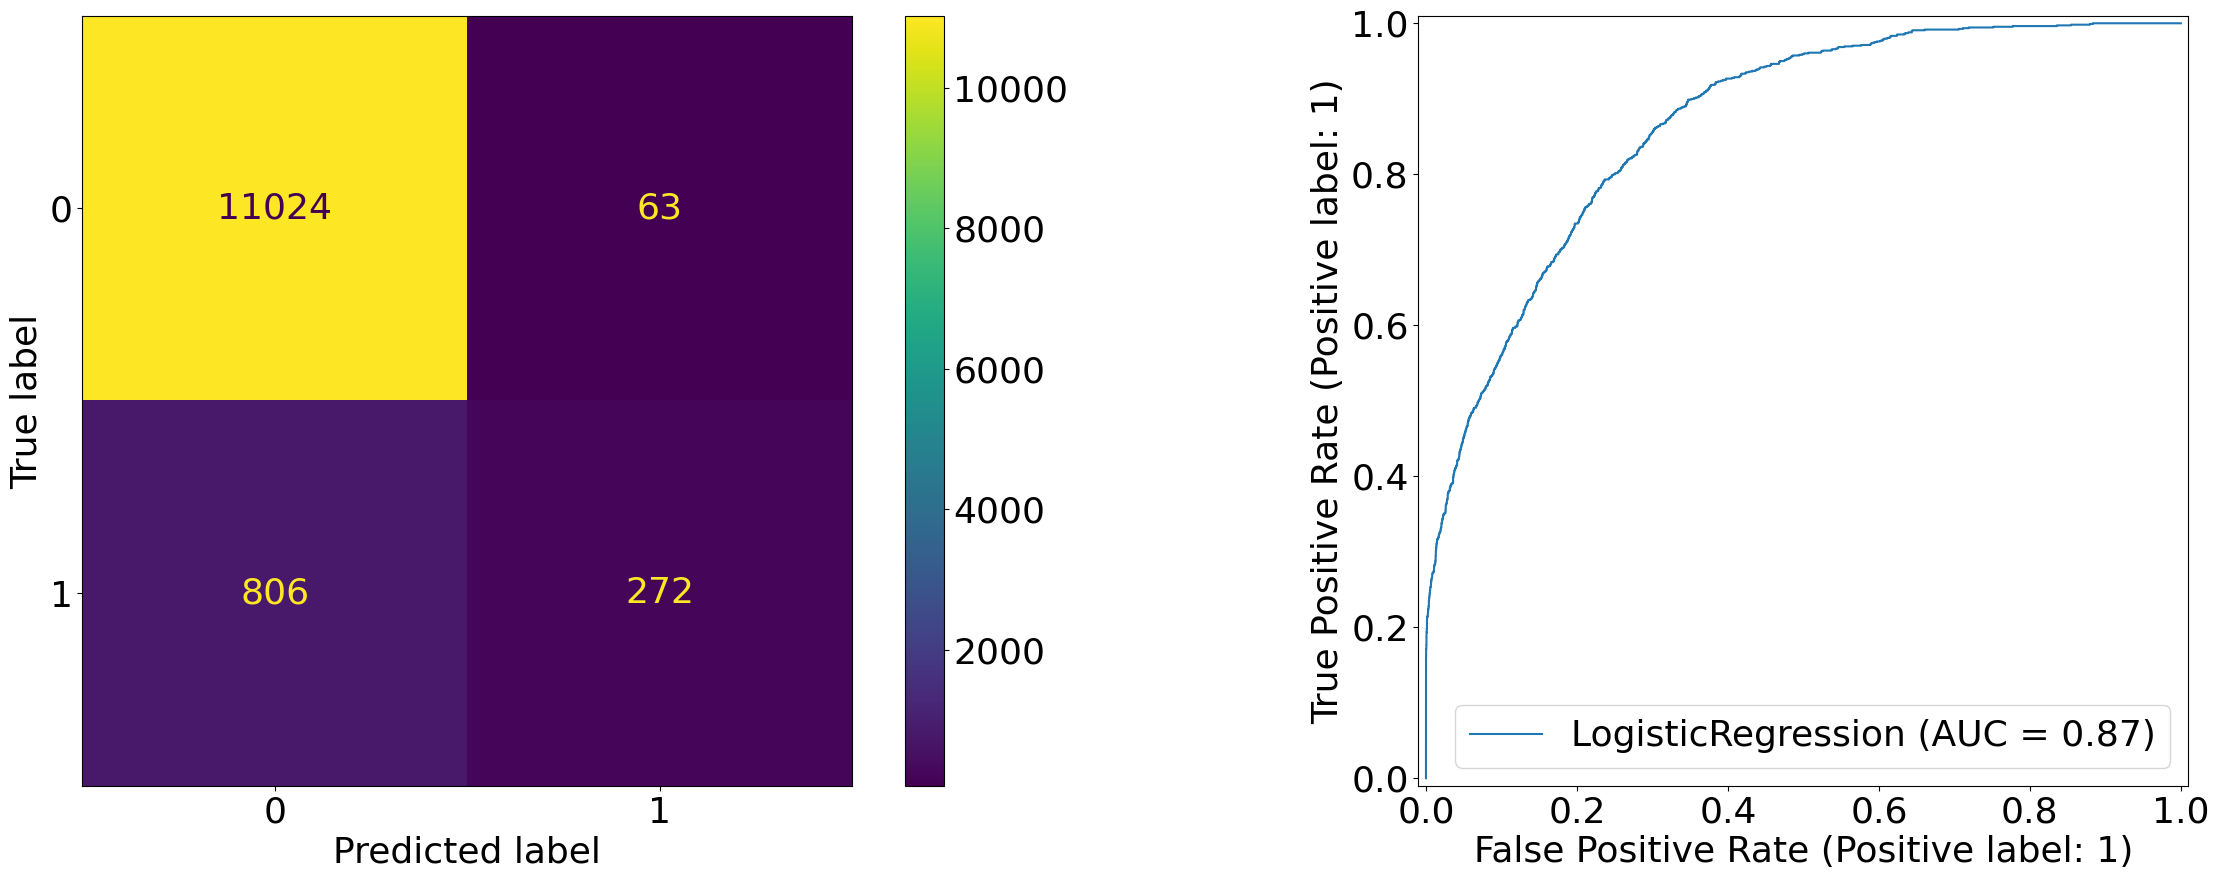

In [ ]:
plt.rcParams['font.size'] = 26
fig, axes = plt.subplots(ncols= 2, figsize = (30, 10))
ConfusionMatrixDisplay.from_estimator(lg, X_val, y_val, ax = axes[0])
RocCurveDisplay.from_estimator(lg, X_val, y_val, ax = axes[1])
plt.show()

In [151]:
y_pred = lg.predict(X_train)
print(classification_report(y_train, y_pred))

              precision    recall  f1-score   support

           0       0.93      1.00      0.96     33341
           1       0.84      0.25      0.39      3154

    accuracy                           0.93     36495
   macro avg       0.88      0.62      0.67     36495
weighted avg       0.93      0.93      0.91     36495



In [152]:
y_val_pred = lg.predict(X_val)
print(classification_report(y_val, y_val_pred))

              precision    recall  f1-score   support

           0       0.93      0.99      0.96     11087
           1       0.81      0.25      0.38      1078

    accuracy                           0.93     12165
   macro avg       0.87      0.62      0.67     12165
weighted avg       0.92      0.93      0.91     12165



In [153]:
df_drop.describe()

,gender,no_of_trainings,age,previous_year_rating,length_of_service,KPI_met,awards_won,avg_training_score,is_promoted,department_Finance,...,region_region_4,region_region_5,region_region_6,region_region_7,region_region_8,region_region_9,education_Below Secondary,education_Master's & above,recruitment_channel_referred,recruitment_channel_sourcing
count,48660.000000,48660.000000,48660.000000,48660.000000,48660.00000,48660.000000,48660.00000,48660.000000,48660.000000,48660.000000,...,48660.000000,48660.000000,48660.000000,48660.000000,48660.000000,48660.000000,48660.000000,48660.000000,48660.000000,48660.000000
mean,0.695684,1.251993,35.589437,3.337526,6.31157,0.356473,0.02314,63.603309,0.086971,0.045602,...,0.033416,0.014180,0.011899,0.090362,0.011878,0.006658,0.009412,0.304110,0.020962,0.423818
std,0.460122,0.604994,7.534571,1.257922,4.20476,0.478962,0.15035,13.273502,0.281795,0.208623,...,0.179721,0.118234,0.108432,0.286702,0.108340,0.081328,0.096560,0.460034,0.143258,0.494167
min,0.000000,1.000000,20.000000,1.000000,1.00000,0.000000,0.00000,39.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.000000,1.000000,30.000000,3.000000,3.00000,0.000000,0.00000,51.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,1.000000,1.000000,34.000000,3.000000,5.00000,0.000000,0.00000,60.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,1.000000,1.000000,39.000000,4.000000,8.00000,1.000000,0.00000,76.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,1.000000
max,1.000000,10.000000,60.000000,5.000000,37.00000,1.000000,1.00000,99.000000,1.000000,1.000000,...,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


In [154]:
ld = LogisticRegression()

In [185]:
cols_num = ['no_of_trainings', 'age', 'length_of_service', 'avg_training_score']
scaler = StandardScaler()
X_train_scale = X_train.copy()
X_val_scale = X_val.copy()

X_train_scale[cols_num] = scaler.fit_transform(X_train_scale[cols_num])
X_val_scale[cols_num] = scaler.transform(X_val_scale[cols_num])

In [188]:
grid = GridSearchCV(estimator=lg, param_grid={
    'C': [6, 7, 8],
    'solver': ['lbfgs'],
    'class_weight': [None, 'balanced'],
})
grid.fit(X_train, y_train)
grid.best_score_, grid.best_params_

(np.float64(0.931442663378545),
 {'C': 8, 'class_weight': None, 'solver': 'lbfgs'})

In [166]:
lg_ajust= LogisticRegression(random_state=2026, C= 7)
lg_ajust.fit(X_train_scale, y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",7
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",2026
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`multi

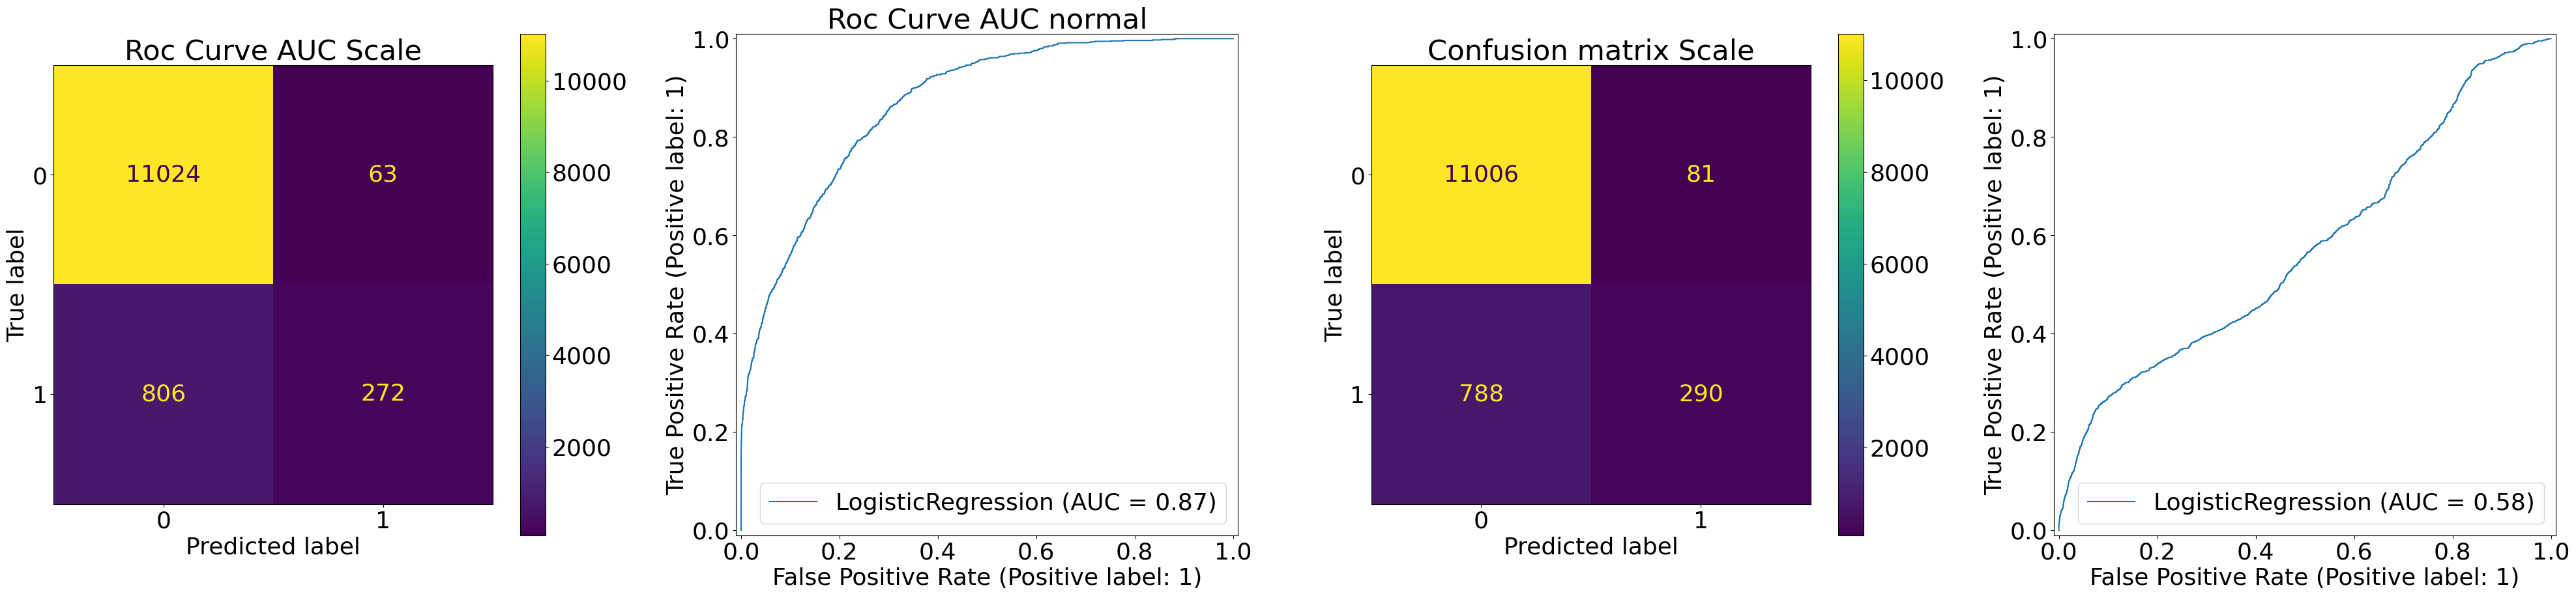

In [157]:
plt.rcParams['font.size'] = 26
fig, axes = plt.subplots(ncols= 4, figsize = (50, 10))
ConfusionMatrixDisplay.from_estimator(lg, X_val, y_val, ax = axes[0])
axes[0].set_title('Confusion matrix normal')
RocCurveDisplay.from_estimator(lg, X_val, y_val, ax = axes[1])
axes[1].set_title('Roc Curve AUC normal')
ConfusionMatrixDisplay.from_estimator(lg_ajust, X_val_scale, y_val, ax = axes[2])
axes[2].set_title('Confusion matrix Scale')
RocCurveDisplay.from_estimator(lg, X_val_scale, y_val, ax = axes[3])
axes[0].set_title('Roc Curve AUC Scale')
plt.show()

In [139]:
y_train.value_counts()

is_promoted
0    33341
1     3154
Name: count, dtype: int64

## Over sampling

In [170]:
smote = SMOTE()
X_train_res, y_train_res = smote.fit_resample(X_train_scale, y_train)

In [171]:
y_train.value_counts()

is_promoted
0    33341
1     3154
Name: count, dtype: int64

In [172]:
y_train_res.value_counts()

is_promoted
0    33341
1    33341
Name: count, dtype: int64

In [174]:
X_train_res.shape, y_val_pred.shape

((66682, 53), (12165,))

In [159]:
lg = LogisticRegression(random_state=2026, max_iter=200)
lg.fit(X_train_res, y_train_res)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",2026
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

In [175]:
lg_res = LogisticRegression(random_state=2026, max_iter=1000)
lg_res.fit(X_train_res, y_train_res)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",2026
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

In [187]:
grid = GridSearchCV(estimator=lg_res, param_grid={
    'C': [6, 7, 8],
    'solver': ['lbfgs', 'liblinear'],
})

grid.fit(X_train_scale, y_train)
grid.best_score_, grid.best_params_

(np.float64(0.9315796684477325), {'C': 7, 'solver': 'lbfgs'})

In [177]:
lg_res = LogisticRegression(random_state=2026, max_iter=1000, C=7, solver='lbfgs')
lg_res.fit(X_train_res, y_train_res)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",7
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",2026
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`multi

In [178]:
lg_res.score(X_train_scale, y_train), lg_res.score(X_val_scale, y_val)

(0.7973969036854364, 0.7962186600904233)

In [179]:
y_val_pred = lg_res.predict(X_val_scale)
print(classification_report(y_val, y_val_pred))

              precision    recall  f1-score   support

           0       0.95      0.82      0.88     11087
           1       0.23      0.57      0.33      1078

    accuracy                           0.80     12165
   macro avg       0.59      0.69      0.61     12165
weighted avg       0.89      0.80      0.83     12165



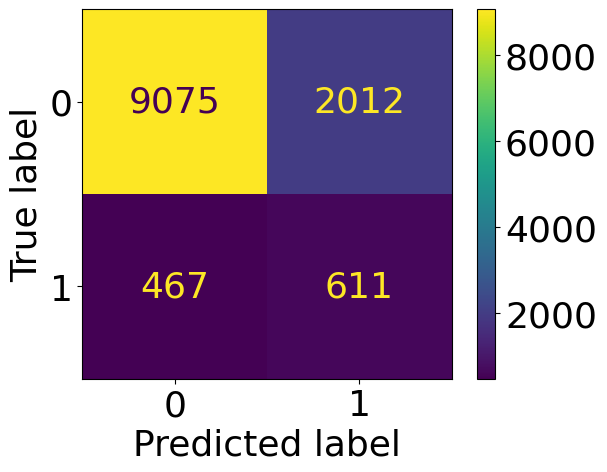

In [180]:
ConfusionMatrixDisplay.from_estimator(lg_res, X_val_scale, y_val)
plt.show()

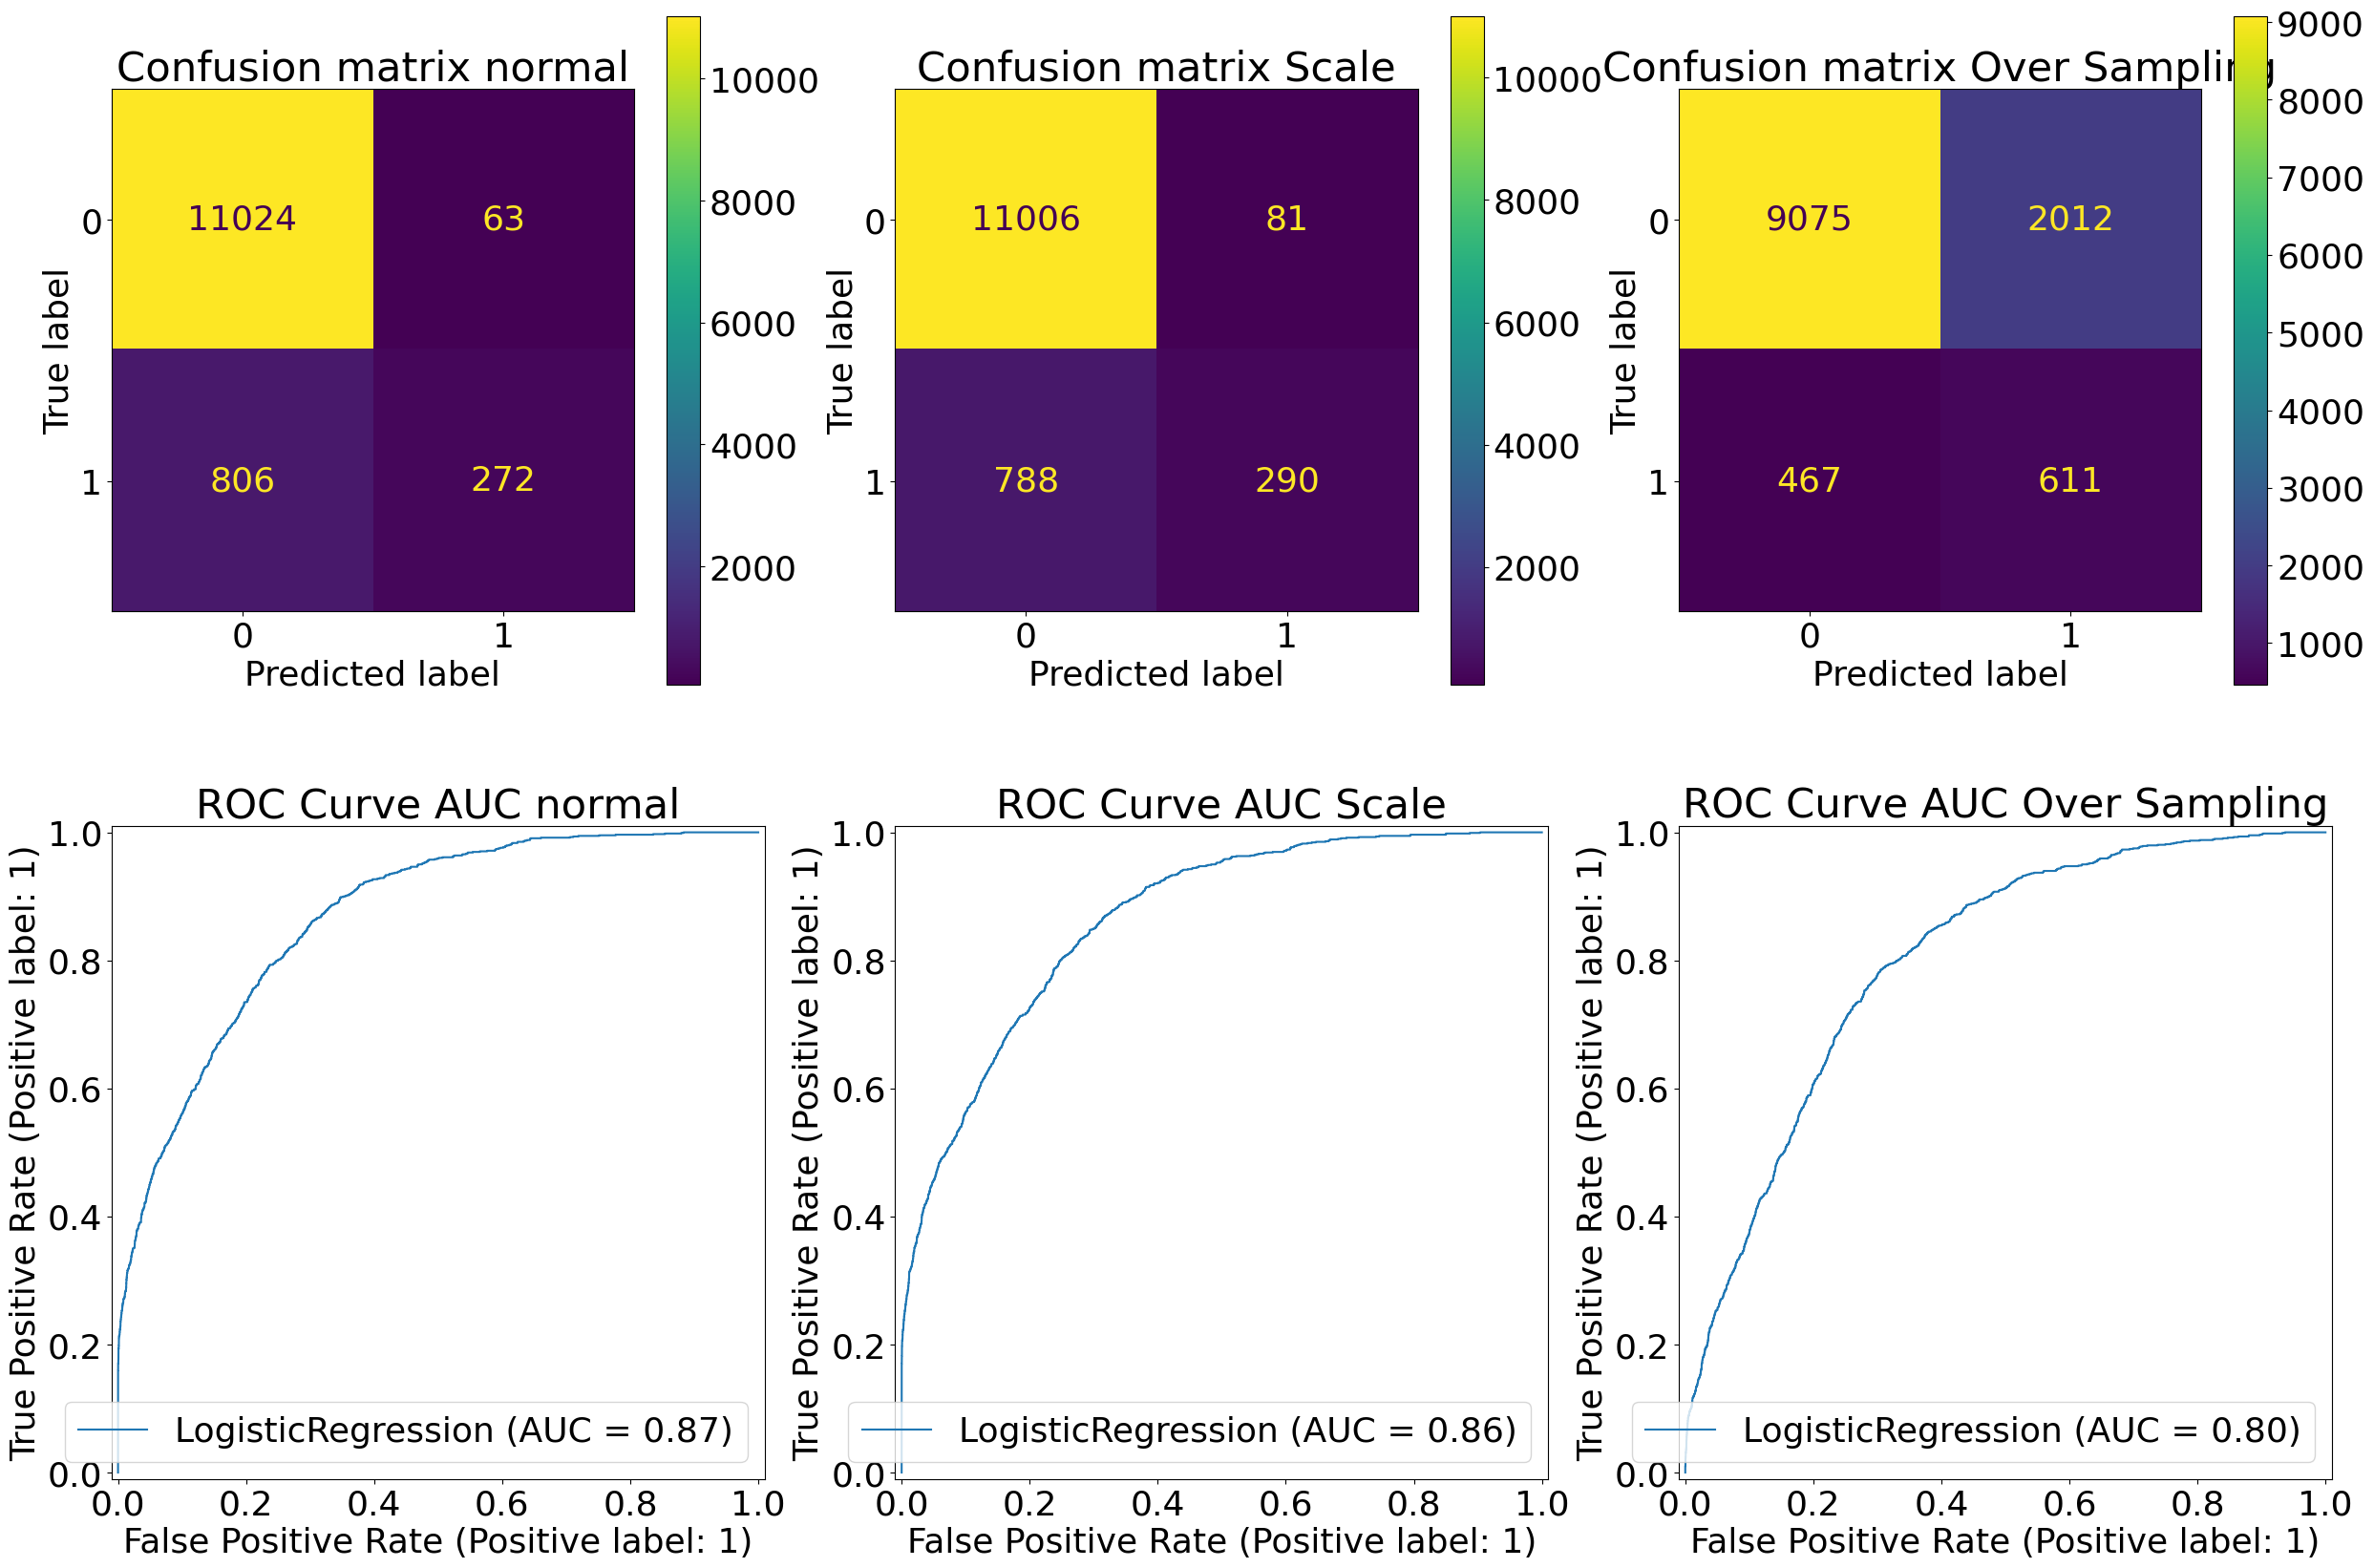

In [ ]:
plt.rcParams['font.size'] = 26
fig, axes = plt.subplots(ncols = 3, nrows = 2, figsize = (30, 20))
ConfusionMatrixDisplay.from_estimator(lg, X_val, y_val, ax=axes[0][0])
axes[0][0].set_title('Confusion matrix normal')
ConfusionMatrixDisplay.from_estimator(lg_ajust, X_val_scale, y_val, ax=axes[0][1])
axes[0][1].set_title('Confusion matrix Scale')
ConfusionMatrixDisplay.from_estimator(lg_res, X_val_scale, y_val, ax=axes[0][2])
axes[0][2].set_title('Confusion matrix Over Sampling')
RocCurveDisplay.from_estimator(lg, X_val, y_val, ax=axes[1][0])
axes[1][0].set_title('ROC Curve AUC normal')
RocCurveDisplay.from_estimator(lg_ajust, X_val_scale, y_val, ax=axes[1][1])
axes[1][1].set_title('ROC Curve AUC Scale')
RocCurveDisplay.from_estimator(lg_res, X_val_scale, y_val, ax=axes[1][2])
axes[1][2].set_title('ROC Curve AUC Over Sampling')

plt.show()

## Compare LogisticRegression vs SGDClassifier vs MLPClassifier vs SVC

In [182]:
sgd = SGDClassifier()
sgd.fit(X_train_res, y_train_res)
sgd.score(X_train_scale, y_train), sgd.score(X_val_scale, y_val)

(0.7785998081929031, 0.7766543362104398)

In [ ]:
grid = GridSearchCV(estimator=sgd, param_grid={
    'eta0': [0.11, 0.12, 0.13],
    'loss': ['hinge', 'log_loss']
})

grid.fit(X_train_res, y_train_res)
grid.best_score_, grid.best_params_

(np.float64(0.8110739889961576), {'eta0': 0.12, 'loss': 'hinge'})

In [190]:
sgd = SGDClassifier(eta0=0.11)
sgd.fit(X_train_res, y_train_res)
sgd.score(X_train_scale, y_train), sgd.score(X_val_scale, y_val)

(0.7597753116865325, 0.7550349362926428)

In [191]:
mlp = MLPClassifier(max_iter=500)
mlp.fit(X_train_res, y_train_res)
mlp.score(X_train_scale, y_train), mlp.score(X_val_scale, y_val)

(0.8840389094396492, 0.8364159473900534)

In [193]:
svc = SVC()
svc.fit(X_train_res, y_train_res)
svc.score(X_train_scale, y_train), svc.score(X_val_scale, y_val)

(0.8203589532812714, 0.809206740649404)

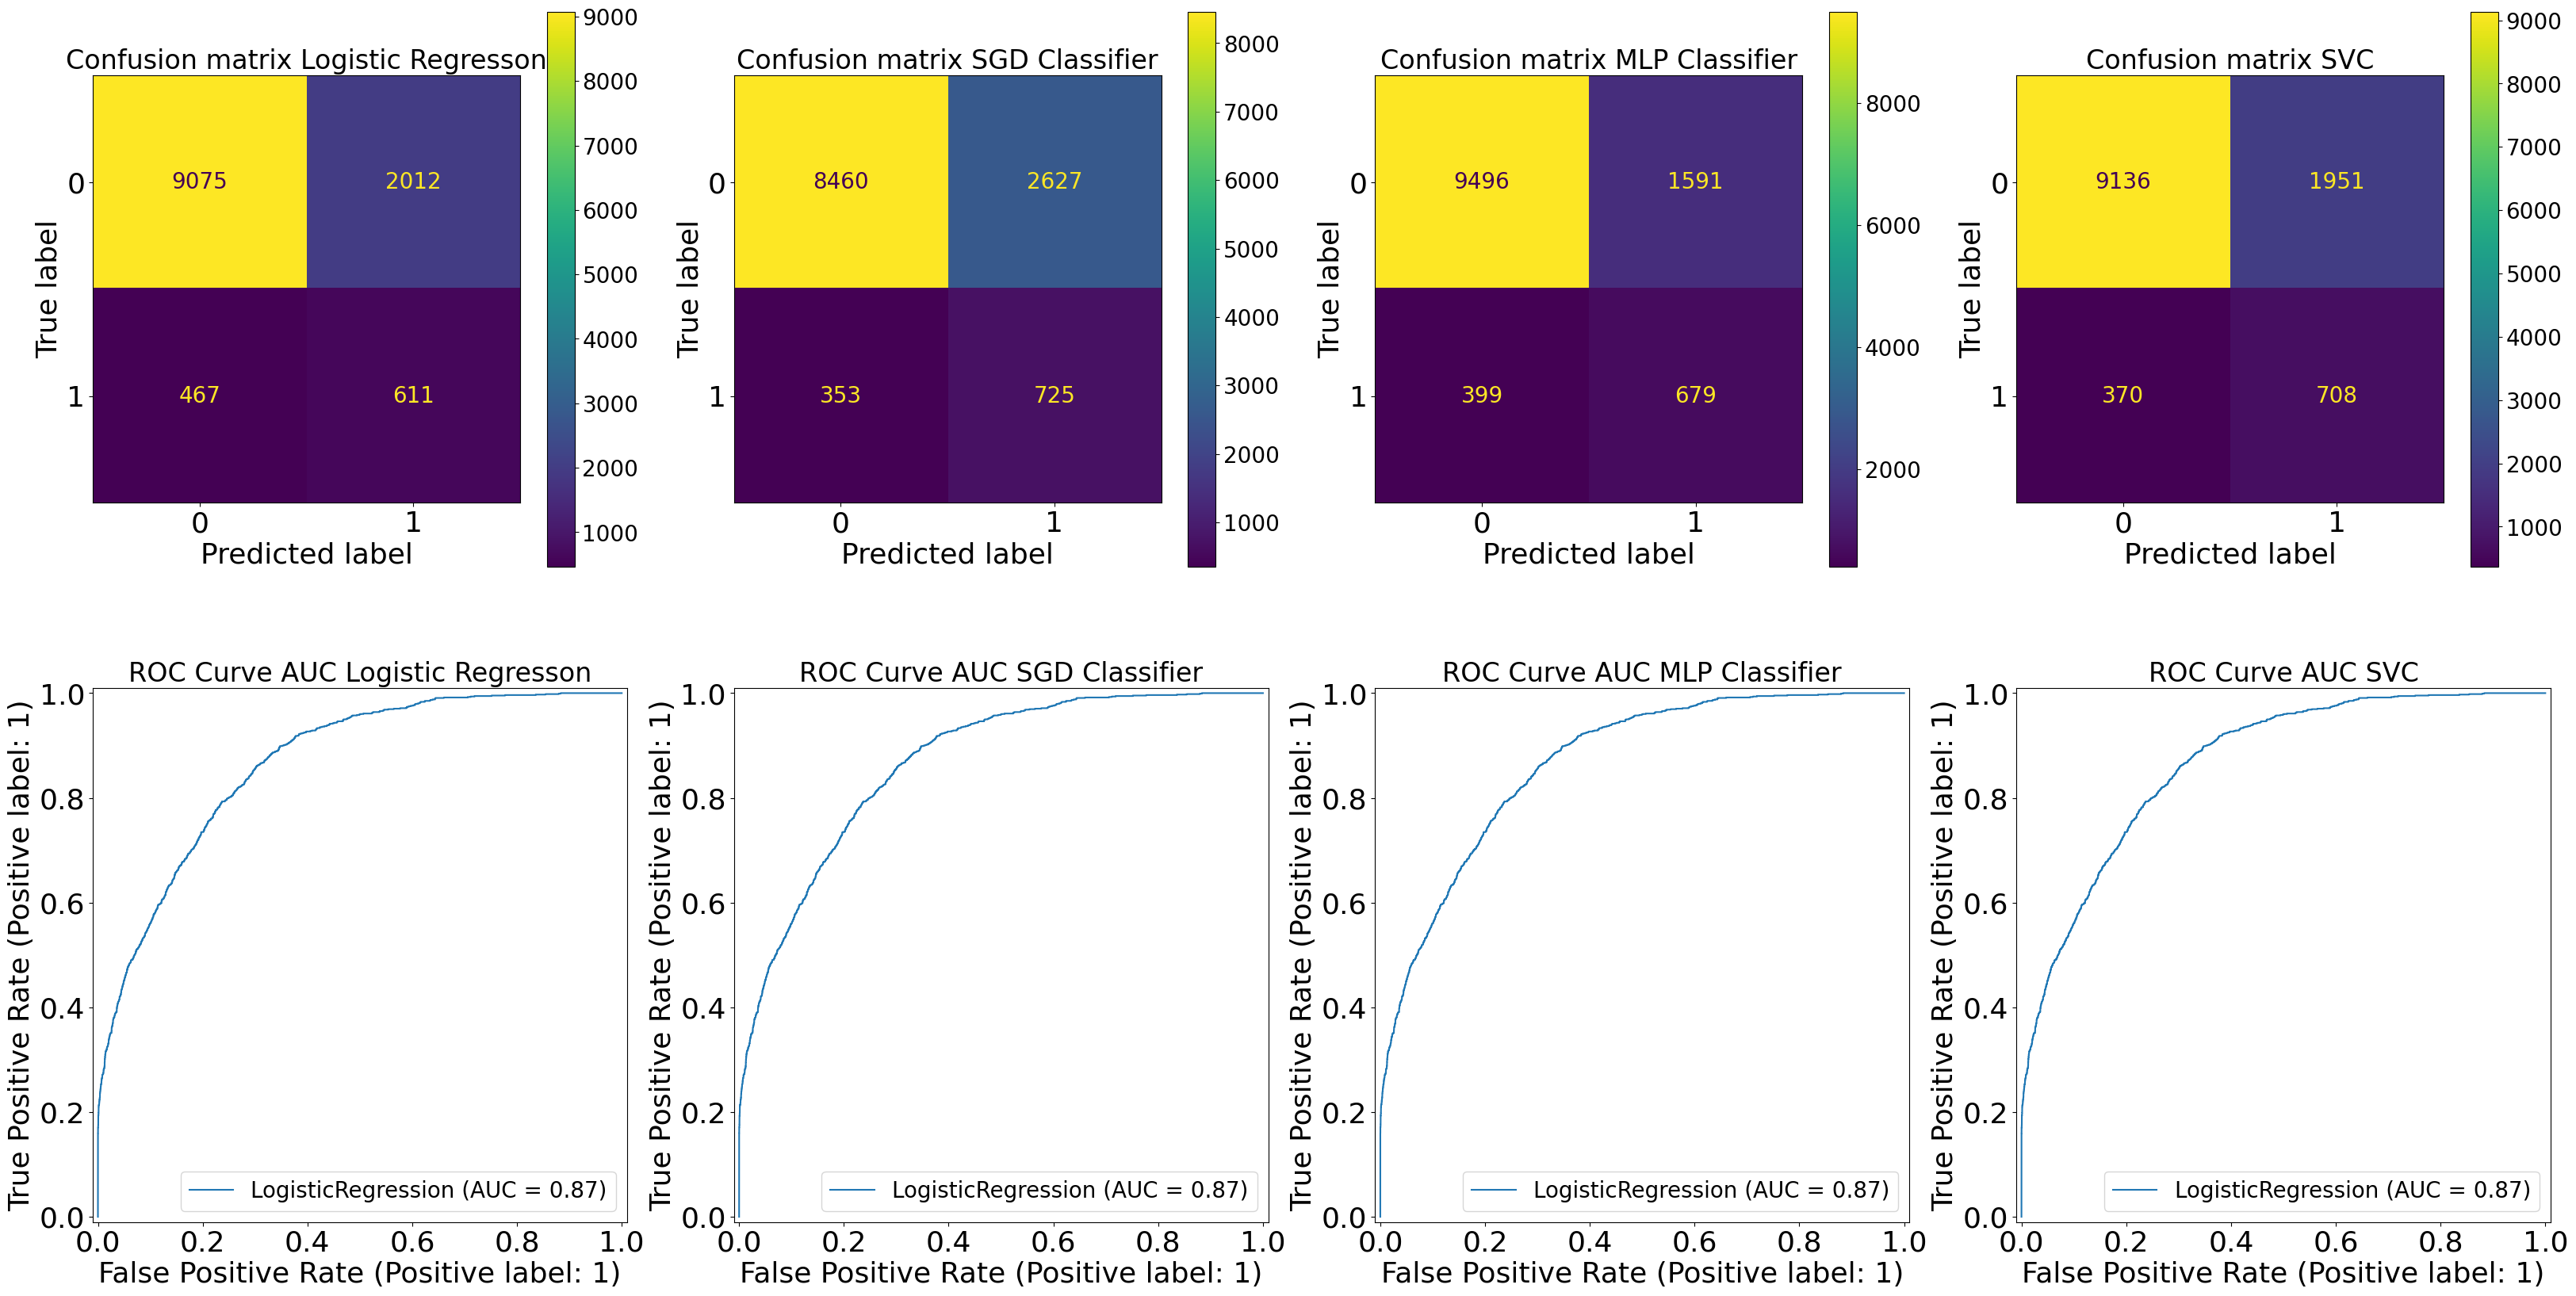

In [208]:
models = {
    'Logistic Regresson': lg_res,
    'SGD Classifier': sgd,
    'MLP Classifier': mlp,
    'SVC': svc
}

fig, axes = plt.subplots(ncols = 4, nrows=2, figsize = (40, 20))
plt.rcParams['font.size'] = 20

for i, name in enumerate(models):
    ConfusionMatrixDisplay.from_estimator(models[name], X_val_scale, y_val, ax=axes[0][i])
    axes[0][i].set_title(f'Confusion matrix {name}')
    
    RocCurveDisplay.from_estimator(lg, X_val, y_val, ax=axes[1][i])
    axes[1][i].set_title(f'ROC Curve AUC {name}')

plt.show()

In [1]:
1250080179 % 31

2